In [1]:

import numpy as np 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/Testing_set.csv
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_4378.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_747.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_561.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_345.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3019.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_2566.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3156.jpg
/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_3889.jpg
/kaggle/input/human-action-recognition-har-dataset

1| HAR là gì?

Human Activity Recognition (HAR) – hay còn gọi là nhận dạng hoạt động của con người – là một lĩnh vực nghiên cứu rộng, tập trung vào việc xác định chuyển động hoặc hành động cụ thể của một người dựa trên dữ liệu cảm biến.
Các chuyển động này thường là những hoạt động phổ biến trong đời sống hàng ngày, như đi bộ, nói chuyện, đứng, hoặc ngồi.
*Tại sao HAR lại quan trọng?

Nhận dạng hoạt động của con người đóng vai trò rất quan trọng trong việc hiểu và mô phỏng tương tác giữa người với người, cũng như trong các mối quan hệ xã hội. Vì HAR cung cấp thông tin về danh tính, tính cách và trạng thái tâm lý của một người – những yếu tố khó trích xuất – nên nó trở thành một thách thức lớn trong nghiên cứu. Khả năng của con người trong việc nhận biết hành động của người khác là một trong những chủ đề trọng tâm của các lĩnh vực thị giác máy tính (computer vision) và học máy (machine learning).
Nhờ các nghiên cứu trong lĩnh vực này, nhiều ứng dụng thực tế đã ra đời, bao gồm:

Hệ thống giám sát bằng video,

Giao tiếp người–máy (human-computer interaction),

Robot mô phỏng hành vi con người,

Và các hệ thống nhận dạng đa hoạt động phục vụ phân tích hành vi.

## 2| Importing thư viện

In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Activation, Dropout, Flatten, Dense,BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from PIL import Image

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, 
    EarlyStopping, 
    ModelCheckpoint
)

import seaborn as sns
import matplotlib.image as img
import matplotlib.pyplot as plt


/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


# 3| Tải dữ liệu
Dữ liệu được lấy từ nguồn https://www.kaggle.com/code/kirollosashraf/human-action-recognition-har.

Là các ảnh tĩnh có số lượng ảnh vừa phải, chứa 15 lớp hoạt động của con người ( 15 activity classes): calling, clapping, cycling, dancing, drinking, eating, fighting, hugging, laughing, listening_to_music, running, sitting, sleeping, texting, using_laptop.

Có 12 600 ảnh cho huấn luyện-train- và 5400 ảnh cho kiểm trả-test.
Mỗi ảnh là một người.



In [3]:
# file training_set.csv(12600) chứa 2 cột 1 là tên file ảnh, 2 là nhãn -classify-
train_data = pd.read_csv("../input/human-action-recognition-har-dataset/Human Action Recognition/Training_set.csv")

In [4]:
# folder train chứa ảnh cho huấn luyện 
train_fol = glob.glob("../input/human-action-recognition-har-dataset/Human Action Recognition/train/*") 

In [5]:
train_data

,filename,label
0,Image_1.jpg,sitting
1,Image_2.jpg,using_laptop
2,Image_3.jpg,hugging
3,Image_4.jpg,sleeping
4,Image_5.jpg,using_laptop
...,...,...
12595,Image_12596.jpg,sitting
12596,Image_12597.jpg,clapping
12597,Image_12598.jpg,sitting
12598,Image_12599.jpg,dancing


Qua việc đếm số lượng => dataset này cân bằng giữa các lớp

In [6]:
train_data.label.value_counts()

label
sitting               840
using_laptop          840
hugging               840
sleeping              840
drinking              840
clapping              840
dancing               840
cycling               840
calling               840
laughing              840
eating                840
fighting              840
listening_to_music    840
running               840
texting               840
Name: count, dtype: int64

In [7]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 97.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [8]:
import plotly.express as px

HAR = train_data.label.value_counts().reset_index()
HAR.columns = ['label', 'count']

fig = px.pie(
    HAR,
    values='count',
    names='label',
    title='Distribution of Human Activity'
)
fig.show()

In [9]:
# tên ảnh
filename = train_data['filename']
# lable hoạt động
situation = train_data['label']

In [10]:
filename

0            Image_1.jpg
1            Image_2.jpg
2            Image_3.jpg
3            Image_4.jpg
4            Image_5.jpg
              ...       
12595    Image_12596.jpg
12596    Image_12597.jpg
12597    Image_12598.jpg
12598    Image_12599.jpg
12599    Image_12600.jpg
Name: filename, Length: 12600, dtype: object

# 4| Xây dựng hàm để hiện thị ảnh ngẫu nhiên

In [11]:
def displaying_random_images():
    num = random.randint(1,10000)
    imgg = "Image_{}.jpg".format(num)
    train = "../input/human-action-recognition-har-dataset/Human Action Recognition/train/"
    if os.path.exists(train+imgg):
        testImage = img.imread(train+imgg)
        plt.imshow(testImage)
        plt.title("{}".format(train_data.loc[train_data['filename'] == "{}".format(imgg), 'label'].item()))

    else:
        #print(train+img)
        print("File Path not found \nSkipping the file!!")

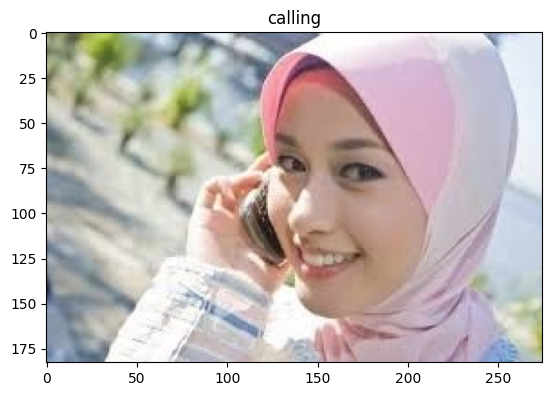

In [12]:
displaying_random_images()

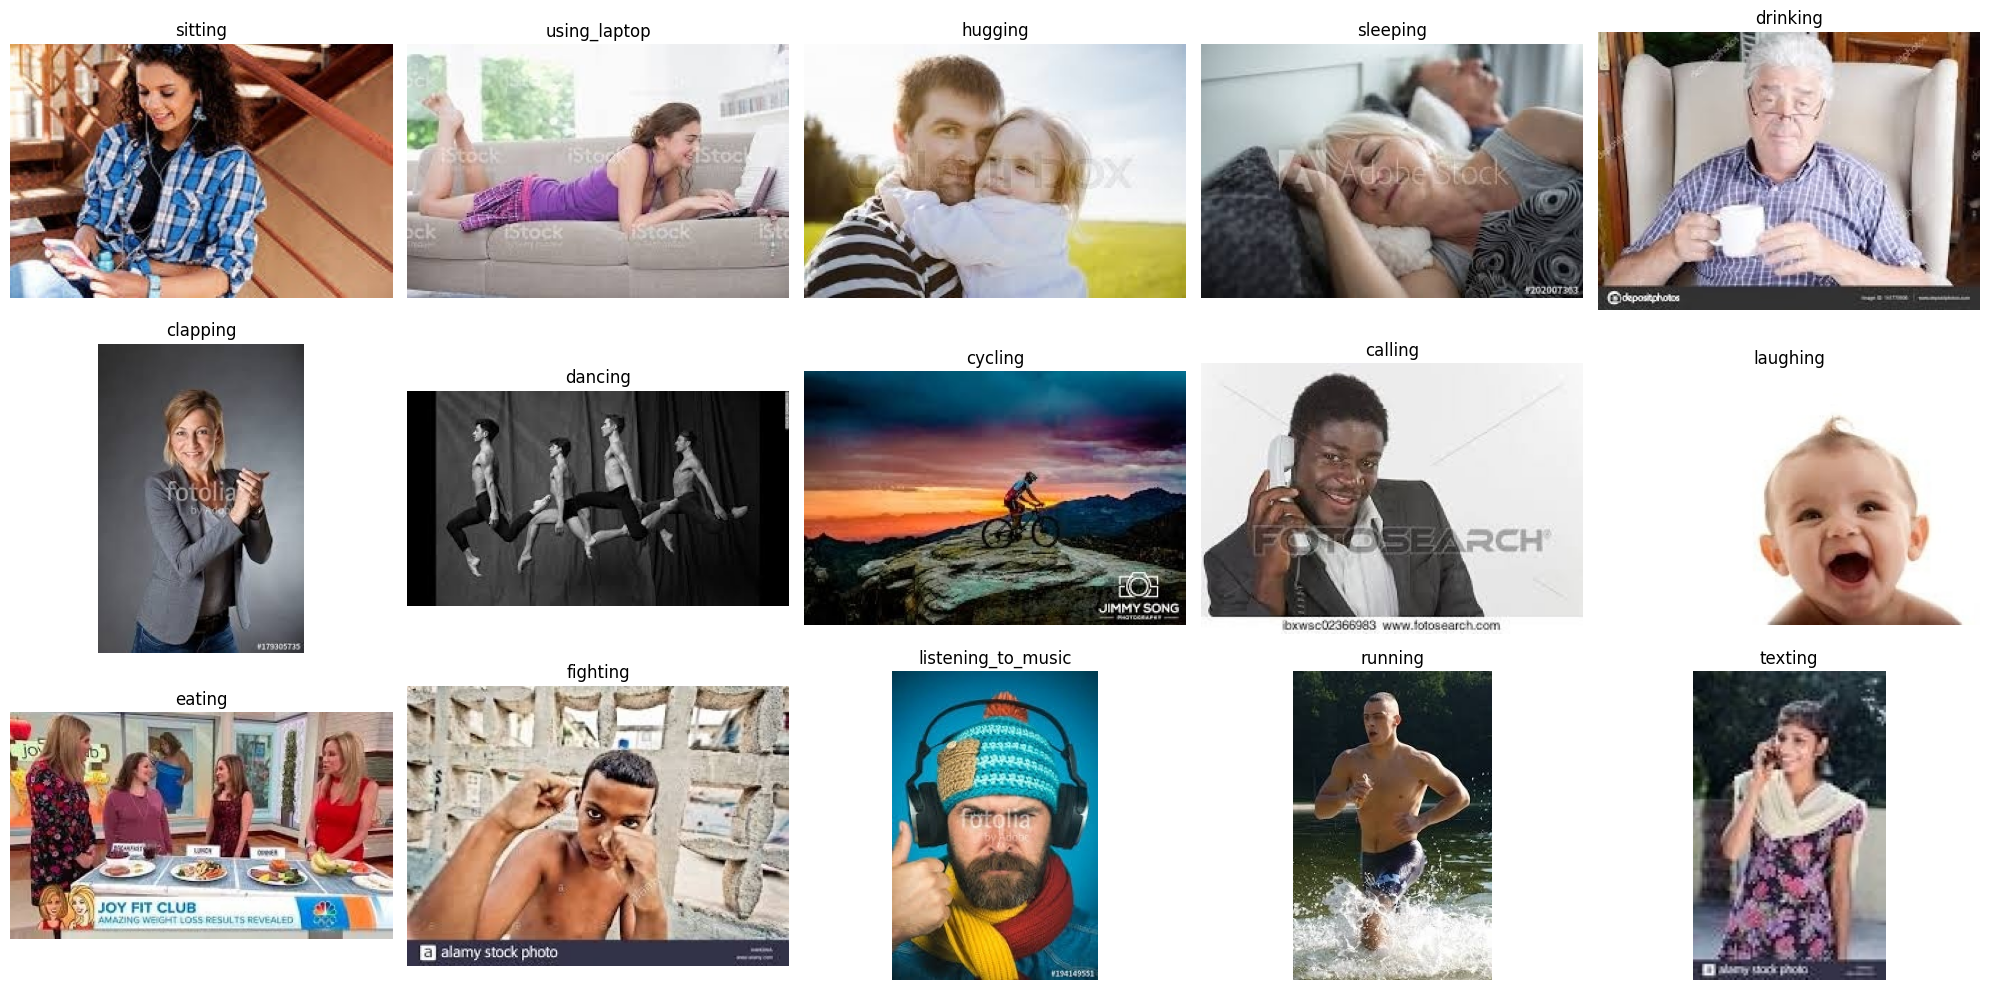

In [13]:
# 📁 Đường dẫn thư mục dataset
train_folder = "../input/human-action-recognition-har-dataset/Human Action Recognition/train"
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()
for idx, class_name in enumerate(train_data['label'].unique()):
    class_images = train_data[train_data['label'] == class_name]['filename'].values
    img = plt.imread(os.path.join(train_folder, class_images[0]))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name)
    axes[idx].axis('off')
plt.tight_layout()
plt.show()

# 5. tiền xử lí dữ liệu sử dụng IMAGEDATAGENERATOR ( Khống tốn RAM)

Resize kích thước ảnh về một kích thước (160*160)

ColorJitter:  Tăng độ đa dạng dữ liệu — mô phỏng điều kiện ánh sáng, màu sắc khác nhau.

Horizontal Flip: Giúp mô hình học được tính “bất biến theo hướng” (orientation invariance) — ví dụ người đi trái hay đi phải đều là “đi bộ”.

Normalize: Chuẩn hóa phân phối pixel để mô hình học ổn định hơn bằng cách trừ đi giá trị trung bình và chia cho độ lệch chuẩn của từng kênh màu, giúp dữ liệu đầu vào có trung bình ≈ 0 và độ lệch chuẩn ≈ 1, giúp mô hình học ổn định hơn.”.

In [ ]:
# EfficientNet pretrained ImageNet cần input [-1,1] với mean/std cụ thể
from tensorflow.keras.applications.efficientnet import preprocess_input
#  Augmentation dành riêng cho train
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   
    rotation_range=25,
    width_shift_range=0.15, 
    height_shift_range=0.15, 
    shear_range=0.1, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    brightness_range=[0.8, 1.2], 
    fill_mode='nearest', 
    validation_split=0.2    
)

# Validation không cần augment, chỉ cần normalize
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)



Chuyển đổi label từ kí tự sang số sử dụng onehot vecto vì model sử dụng được huấn luyện theo dạng phân loại nhiều lớp: 

    label đang là string nên cần sử dụng LabelEncode để chuyển sang số và từ đó sử dụng onehot.

    Sử dụng LableEncode để có thể lưu và dùng chuyển đổi ngược về string trong quá trình regconition

Quá trình chia dữ liệu thành Tran và validation (8:2)

In [ ]:
# TRAIN GENERATOR
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_folder,
    x_col="filename",
    y_col="label",
    target_size=(160, 160),    
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)
# VALIDATION GENERATOR (không augment)
val_gen = val_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_folder,
    x_col="filename",
    y_col="label",
    target_size=(160, 160),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
import joblib
# Lưu tên lớp để dự đoán sau (thay cho LabelEncoder)
class_names = list(train_gen.class_indices.keys())
joblib.dump(class_names, "class_names.pkl")
print("Class names:", class_names)
print(f"Train samples: {train_gen.samples}")
print(f"Val samples: {val_gen.samples}")

Found 10080 validated image filenames belonging to 15 classes.
Found 2520 validated image filenames belonging to 15 classes.
Class names: ['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop']
Train samples: 10080
Val samples: 2520


In [16]:
import pandas as pd
import plotly.express as px

# Mapping integer → label
idx_to_label = {v: k for k, v in train_gen.class_indices.items()}

# --- Train set ---
train_counts = pd.Series(train_gen.classes).map(idx_to_label).value_counts().reset_index()
train_counts.columns = ['label', 'count']
train_counts['set'] = 'train'

# --- Validation set ---
val_counts = pd.Series(val_gen.classes).map(idx_to_label).value_counts().reset_index()
val_counts.columns = ['label', 'count']
val_counts['set'] = 'val'

# --- Gộp train và val ---
all_counts = pd.concat([train_counts, val_counts])

# --- Vẽ bar chart so sánh ---
fig = px.bar(
    all_counts,
    x='label',
    y='count',
    color='set',
    barmode='group',
    title='Distribution of Human Activity in Train and Validation Sets'
)
fig.show()


In [17]:
# Xem 1 batch từ train_gen
x_batch, y_batch = next(train_gen)

print("Kích thước ảnh (batch):", x_batch.shape)     # (32, 160, 160, 3)
print("Kích thước nhãn (batch):", y_batch.shape)     # (32, 15) ← ONE-HOT!
print("Nhãn đầu tiên (one-hot):", y_batch[0])
print("Chỉ số lớp có giá trị 1:", np.argmax(y_batch[0]))
print("Tên hành động:", class_names[np.argmax(y_batch[0])])

Kích thước ảnh (batch): (32, 160, 160, 3)
Kích thước nhãn (batch): (32, 15)
Nhãn đầu tiên (one-hot): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Chỉ số lớp có giá trị 1: 3
Tên hành động: dancing


# 6| Xây dựng kiến trúc model huấn luyện và đánh giá


EfficientNet là một họ mô hình mạng nơ-ron tích chập (CNN) được giới thiệu năm 2019 bởi nhóm nghiên cứu của Google AI (Mingxing Tan & Quoc V. Le) trong bài báo “EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks”.

Khác với các mô hình truyền thống như ResNet hay VGG, EfficientNet sử dụng phương pháp Compound Scaling — một kỹ thuật mở rộng đồng thời chiều sâu (depth), chiều rộng (width) và độ phân giải (resolution) của mạng theo một hệ số chung, giúp tối ưu hiệu quả giữa độ chính xác và tốc độ.

sử dụng mô hình EfficientNetB7 (phiên bản lớn nhất của EfficientNet) được sử dụng.
Mô hình đã được huấn luyện sẵn (pretrained) trên bộ dữ liệu ImageNet và được fine-tune lại để phù hợp với tập dữ liệu hành động con người (Human Action Recognition).

Việc fine-tune giúp mô hình tận dụng được đặc trưng hình ảnh tổng quát đã học được từ ImageNet (như biên dạng, màu sắc, cấu trúc vật thể), đồng thời thích nghi với các đặc trưng riêng của bộ dữ liệu mới.


Fine tune model 

Bước 1: Train giai đoạn 1 (freeze)

In [ ]:
num_classes = len(class_names)

# --- Cấu hình EfficientNetB1 pretrained nếu đủ RAM khuyến khích dùng  EfficientNetB7 ---
base_model = tf.keras.applications.EfficientNetB1(
    include_top=False,          # Bỏ phần fully-connected gốc
    input_shape=(160, 160, 3),  # Kích thước ảnh
    pooling="avg",              # Global Average Pooling
    weights="imagenet"          # Dùng trọng số pretrained ImageNet
)

# Đóng băng các layer pretrained (chưa fine-tune)
for layer in base_model.layers:
    layer.trainable = False

efficientnet_model = Sequential([
    base_model,
    BatchNormalization(),                         
    Dense(512, activation="relu", 
          kernel_regularizer=l2(0.01)),            
    Dropout(0.6),                                  
    BatchNormalization(),                          
    Dense(256, activation="relu",                   
          kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

2025-11-12 05:35:34.565783: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
# Xem cấu trúc model
efficientnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb1 (Functional)     │ (None, 1280)           │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,373,462 (28.13 MB)

 Trainable params: 794,639 (3.03 MB)

 Non-trainable params: 6,578,823 (25.10 MB)

In [ ]:
# thêm label  smoothing giúp mô hình không quá tự tin vì dữ liệu có nhưng hành động tương tự
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# --- Cấu hình optimizer, loss, metrics ---
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=["accuracy"]
)

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',              
        factor=0.5,                     
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',             
        patience=10,                     
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

Huấn luyện

In [ ]:
# Huấn luyện model giai đoạn 1
history_1 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,                          
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.1104 - loss: 13.7051
Epoch 1: val_accuracy improved from None to 0.49881, saving model to best_model.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 155s 462ms/step - accuracy: 0.1459 - loss: 13.2078 - val_accuracy: 0.4988 - val_loss: 11.5593 - learning_rate: 1.0000e-04
Epoch 2/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.2642 - loss: 11.8822
Epoch 2: val_accuracy improved from 0.49881 to 0.57103, saving model to best_model.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 79s 250ms/step - accuracy: 0.2844 - loss: 11.5512 - val_accuracy: 0.5710 - val_loss: 10.2565 - learning_rate: 1.0000e-04
Epoch 3/30
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.3475 - loss: 10.5852
Epoch 3: val_accuracy improved from 0.57103 to 0.60238, saving model to best_model.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 80s 252ms/step - accuracy: 0.3582 - loss: 10.2889 - val_accuracy: 0.6024 - val_loss: 9.1758 - learning_rate: 1.0000e-04
Epoch 4/30
315/315 

Bước 2: Fine-tune EfficientNetB1 (mở khóa các layer cuối)

In [ ]:
# # Mở fine-tune cho các layer cuối cùng của EfficientNetB1
total_layers = len(base_model.layers)
unfreeze_from = int(total_layers * 0.8)

for layer in base_model.layers[:unfreeze_from]:
    layer.trainable = False

for layer in base_model.layers[unfreeze_from:]:
    layer.trainable = True

# Biên dịch lại model với learning rate thấp hơn
efficientnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR thấp hơn 10 lần
    loss=loss_fn,
    metrics=["accuracy"]
)
# Callbacks cho fine-tuning
callbacks_finetune = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=15,                     
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_finetuned.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


In [ ]:
history_2 = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=47,                          
    callbacks=callbacks_finetune,
    verbose=1
)


Epoch 1/47
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.5284 - loss: 2.0973
Epoch 1: val_accuracy improved from None to 0.63730, saving model to best_model_finetuned.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 112s 308ms/step - accuracy: 0.5456 - loss: 2.0529 - val_accuracy: 0.6373 - val_loss: 1.8176 - learning_rate: 1.0000e-05
Epoch 2/47
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.5725 - loss: 1.9861
Epoch 2: val_accuracy improved from 0.63730 to 0.65000, saving model to best_model_finetuned.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 93s 295ms/step - accuracy: 0.5765 - loss: 1.9655 - val_accuracy: 0.6500 - val_loss: 1.7820 - learning_rate: 1.0000e-05
Epoch 3/47
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5878 - loss: 1.9334
Epoch 3: val_accuracy improved from 0.65000 to 0.66548, saving model to best_model_finetuned.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 92s 293ms/step - accuracy: 0.5982 - loss: 1.9087 - val_accuracy: 0.6655 - val_loss: 1.7509 - learning_rate: 1.0000e-

NameError: name 'history_stage1' is not defined

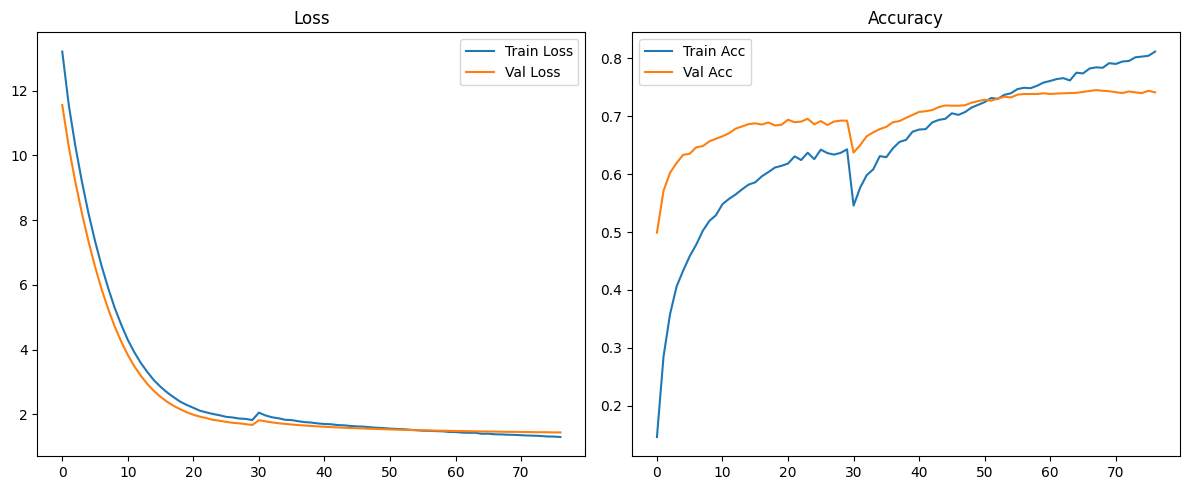

In [24]:
# Ghép lịch sử training lại
history_combined = {
    'loss': history_1.history['loss'] + history_2.history['loss'],
    'val_loss': history_1.history['val_loss'] + history_2.history['val_loss'],
    'accuracy': history_1.history['accuracy'] + history_2.history['accuracy'],
    'val_accuracy': history_1.history['val_accuracy'] + history_2.history['val_accuracy']
}

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_combined['loss'], label='Train Loss')
plt.plot(history_combined['val_loss'], label='Val Loss')
plt.legend(); 
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history_combined['accuracy'], label='Train Acc')
plt.plot(history_combined['val_accuracy'], label='Val Acc')
plt.legend(); 
plt.title('Accuracy')
plt.tight_layout(); 
plt.show()

In [28]:
def read_img(fn):
    img = Image.open(fn)
    return np.asarray(img.resize((160,160)))

In [39]:
# 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

# predict
def test_predict(test_image):
    # đọc ảnh và chuẩn hóa nếu cần
    img_array = np.asarray([read_img(test_image)])
    
    # dự đoán
    result = efficientnet_model.predict(img_array)
    
    # xác suất và index lớp dự đoán
    max_prob = np.max(result)
    pred_index = np.argmax(result)
    pred_class = class_names[pred_index]  # chuyển index -> tên lớp

    print(f"probability: {max_prob*100:.2f}%\nPredicted class: {pred_class}")

    # hiển thị ảnh
    image = mpimg.imread(test_image)
    plt.imshow(image)
    plt.title(pred_class)
    plt.axis('off')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
probability: 33.60%
Predicted class: clapping


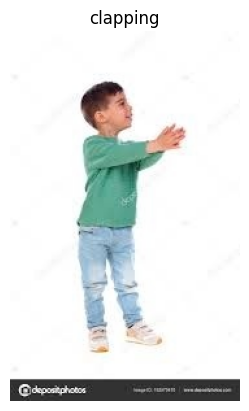

In [40]:
test_predict("/kaggle/input/human-action-recognition-har-dataset/Human Action Recognition/test/Image_1001.jpg")